In [36]:
import pandas as pd
import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

GDP DATA

In [37]:
gdp=pd.read_html("https://www.multpl.com/us-real-gdp-growth-rate/table/by-quarter")

In [38]:
gdp=gdp[0]
gdp.columns=["Date","Value"]

gdp_df=pd.DataFrame(gdp)

#Adding a new column for quarter with format Q1 2010, Q2 2010, etc.

gdp_df["Date"] = pd.to_datetime(gdp_df["Date"], format="%b %d, %Y")

# Get month
month = gdp_df["Date"].dt.month

# Custom mapping: Dec=1, Mar=2, Jun=3, Sep=4
quarter_map = {12: 1, 3: 2, 6: 3, 9: 4}
gdp_df["q_num"] = month.map(quarter_map)

# Build labels like Q1 2025
gdp_df["quarter"] = "Q" + gdp_df["q_num"].astype(str) + " " + gdp_df["Date"].dt.year.astype(str)

# 👉 Fix: any 31-Dec should be Q1 of the next natural year
mask = gdp_df["Date"].dt.month == 12
gdp_df.loc[mask, "quarter"] = "Q1 " + (gdp_df.loc[mask, "Date"].dt.year + 1).astype(str)

# Drop helper column if not needed
gdp_df = gdp_df.drop(columns="q_num")

gdp_df["Value"] = (
    gdp_df["Value"]
    .astype(str)                  # 1. make sure everything is a string
    .str.replace("%","", regex=False)   # 2. remove percent signs
    .str.replace(",","", regex=False)   # 3. remove commas (like "2,345")
    .astype(float)                # 4. convert the cleaned string back to float
)

#Rename Value to gdp_growth
gdp_df = gdp_df.rename(columns={"Value": "gdp_growth", "Date": "date"})

gdp_2009_2025 = gdp_df[
    (gdp_df["date"] >= "2009-03-31") & (gdp_df["date"] <= "2025-06-30")
]


In [39]:
#Drop quarter column if not needed
gdp_2009_2025 = gdp_2009_2025.drop(columns="quarter")

In [40]:
gdp_2009_2025

,date,gdp_growth
0,2025-06-30,1.99
1,2025-03-31,1.99
2,2024-12-31,2.53
3,2024-09-30,2.72
4,2024-06-30,3.04
...,...,...
61,2010-03-31,1.75
62,2009-12-31,0.11
63,2009-09-30,-3.13
64,2009-06-30,-3.98


INTEREST RATES DATA

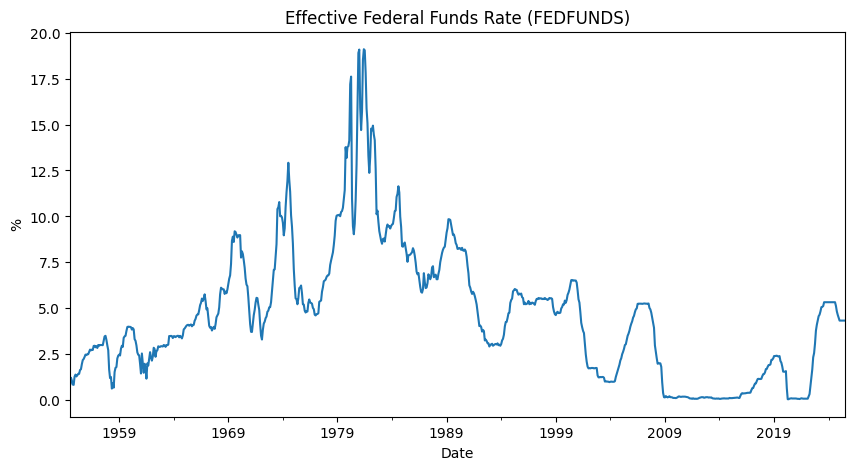

In [41]:
# pip install fredapi

fred = Fred(api_key="8cb2c8aa7bbacefaec8bd2c4baf6f6a3")
interest_rates = fred.get_series("FEDFUNDS")  # pandas Series indexed by date
interest_rates.plot(figsize=(10,5), title="Effective Federal Funds Rate (FEDFUNDS)")
plt.xlabel("Date"); plt.ylabel("%"); plt.show()

In [42]:
interest_rates=pd.DataFrame(interest_rates)
interest_rates=interest_rates.reset_index()

In [43]:
interest_rates=interest_rates.rename(columns={"index":"date",0:"interest_rate"})
interest_rates

,date,interest_rate
0,1954-07-01,0.80
1,1954-08-01,1.22
2,1954-09-01,1.07
3,1954-10-01,0.85
4,1954-11-01,0.83
...,...,...
848,2025-03-01,4.33
849,2025-04-01,4.33
850,2025-05-01,4.33
851,2025-06-01,4.33


In [44]:
interest_rates["date_2"] = interest_rates["date"] - pd.to_timedelta(1, unit="d")
interest_rates=interest_rates.drop(columns="date")
interest_rates=interest_rates.rename(columns={"date_2":"date"})

In [45]:
interest_rates_2009_2025 = interest_rates[
    (interest_rates["date"] >= "2009-03-31") & (interest_rates["date"] <= "2025-06-30")
]
interest_rates_2009_2025=interest_rates_2009_2025.reset_index()
interest_rates_2009_2025=interest_rates_2009_2025.drop(columns="index")

In [46]:
interest_rates_2009_2025

,interest_rate,date
0,0.15,2009-03-31
1,0.18,2009-04-30
2,0.21,2009-05-31
3,0.16,2009-06-30
4,0.16,2009-07-31
...,...,...
191,4.33,2025-02-28
192,4.33,2025-03-31
193,4.33,2025-04-30
194,4.33,2025-05-31


MERGE GDP AND INTERES RATES DFS

In [47]:
#merge gdp_2009_2025 and interest_rates_2009_2025 on date
gdp_interest_rates = pd.merge(gdp_2009_2025, interest_rates_2009_2025, on="date", how="inner")
gdp_interest_rates

,date,gdp_growth,interest_rate
0,2025-06-30,1.99,4.33
1,2025-03-31,1.99,4.33
2,2024-12-31,2.53,4.33
3,2024-09-30,2.72,4.83
4,2024-06-30,3.04,5.33
...,...,...,...
61,2010-03-31,1.75,0.20
62,2009-12-31,0.11,0.11
63,2009-09-30,-3.13,0.12
64,2009-06-30,-3.98,0.16


In [49]:
gdp_interest_rates.to_csv("macro_2009_2025.csv", index=False)